In [2]:
%pip install plotnine[extra]

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 27.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/833.4 kB ? eta -:--:--
   --------------------------------------- 833.4/833.4 kB 35.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/52.0 MB ? eta -:--:--
   ------------------- -------------------- 25.7/52.0 MB 147.8 MB/s eta 0:00:01
   ---------------------------------------  51.9/52.0 MB 150.1 MB/s eta 0:00:01
   ---------------------------------------- 52.0/52.0 MB 127.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/27.3 MB ? eta -:--:--
   ------------------------------------- -- 25.4/27.3 MB 124.0 MB/s eta 0:00:01
   ---------------------------------------- 27.3/27.3 MB 108.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---------------------------------- ----- 19.7/22.9 MB 95.6 MB/s eta 0:00:01
   -----------

c:\Users\paul\programming\courses\python-exercises\.conda\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning: geom_point : Removed 2 rows containing missing values.


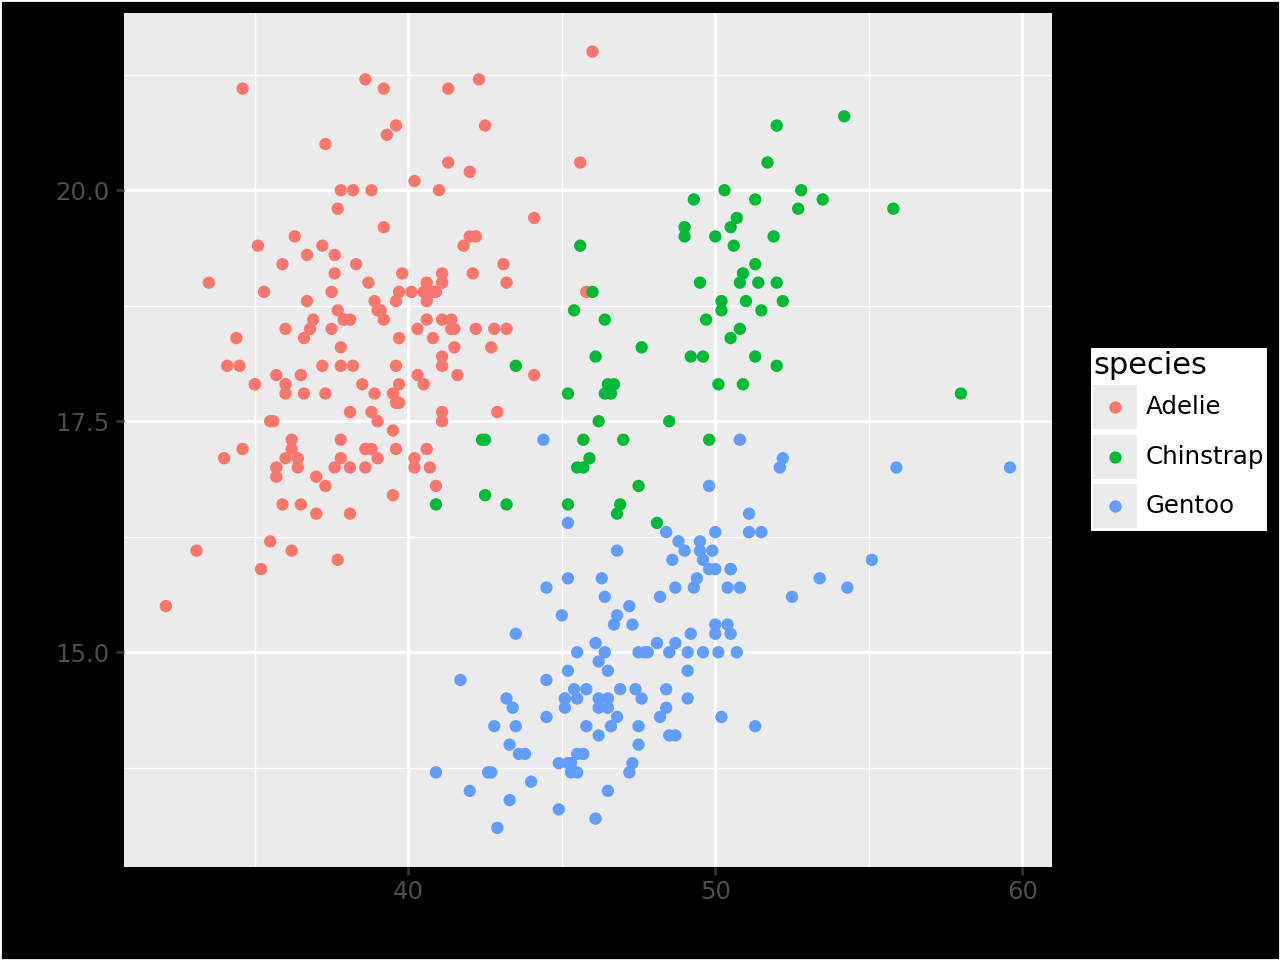

In [6]:
from plotnine import ggplot, aes, geom_point, labs
from plotnine.data import penguins

(
    ggplot(penguins, aes("bill_length_mm", "bill_depth_mm", color="species"))
    + geom_point()
)

In [11]:
import polars as pl

pl_penguins = pl.from_pandas(penguins)
pl_penguins

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
cat,cat,f64,f64,f64,f64,cat,i64
"""Adelie""","""Torgersen""",39.1,18.7,181.0,3750.0,"""male""",2007
"""Adelie""","""Torgersen""",39.5,17.4,186.0,3800.0,"""female""",2007
"""Adelie""","""Torgersen""",40.3,18.0,195.0,3250.0,"""female""",2007
"""Adelie""","""Torgersen""",null,null,null,null,null,2007
"""Adelie""","""Torgersen""",36.7,19.3,193.0,3450.0,"""female""",2007
…,…,…,…,…,…,…,…
"""Chinstrap""","""Dream""",55.8,19.8,207.0,4000.0,"""male""",2009
"""Chinstrap""","""Dream""",43.5,18.1,202.0,3400.0,"""female""",2009
"""Chinstrap""","""Dream""",49.6,18.2,193.0,3775.0,"""male""",2009


c:\Users\paul\programming\courses\python-exercises\.conda\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


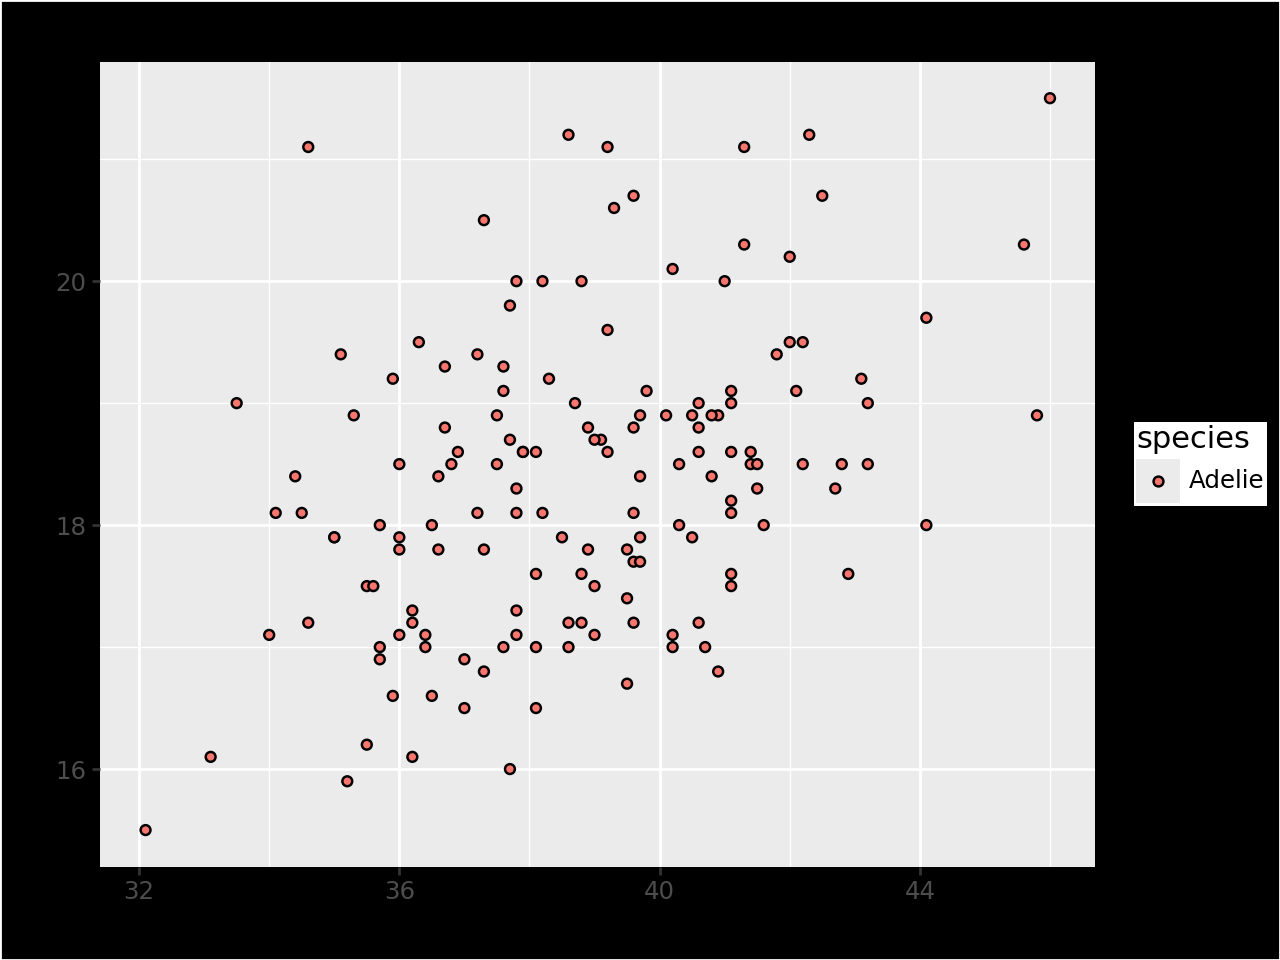

In [13]:
(
    # polars: subset rows  ----
    pl_penguins.filter(pl.col("species") == "Adelie")
    #
    # pipe to plotnine ----
    >> ggplot(aes("bill_length_mm", "bill_depth_mm", fill="species"))
    + geom_point()
    + labs(title="Adelie penguins")
)

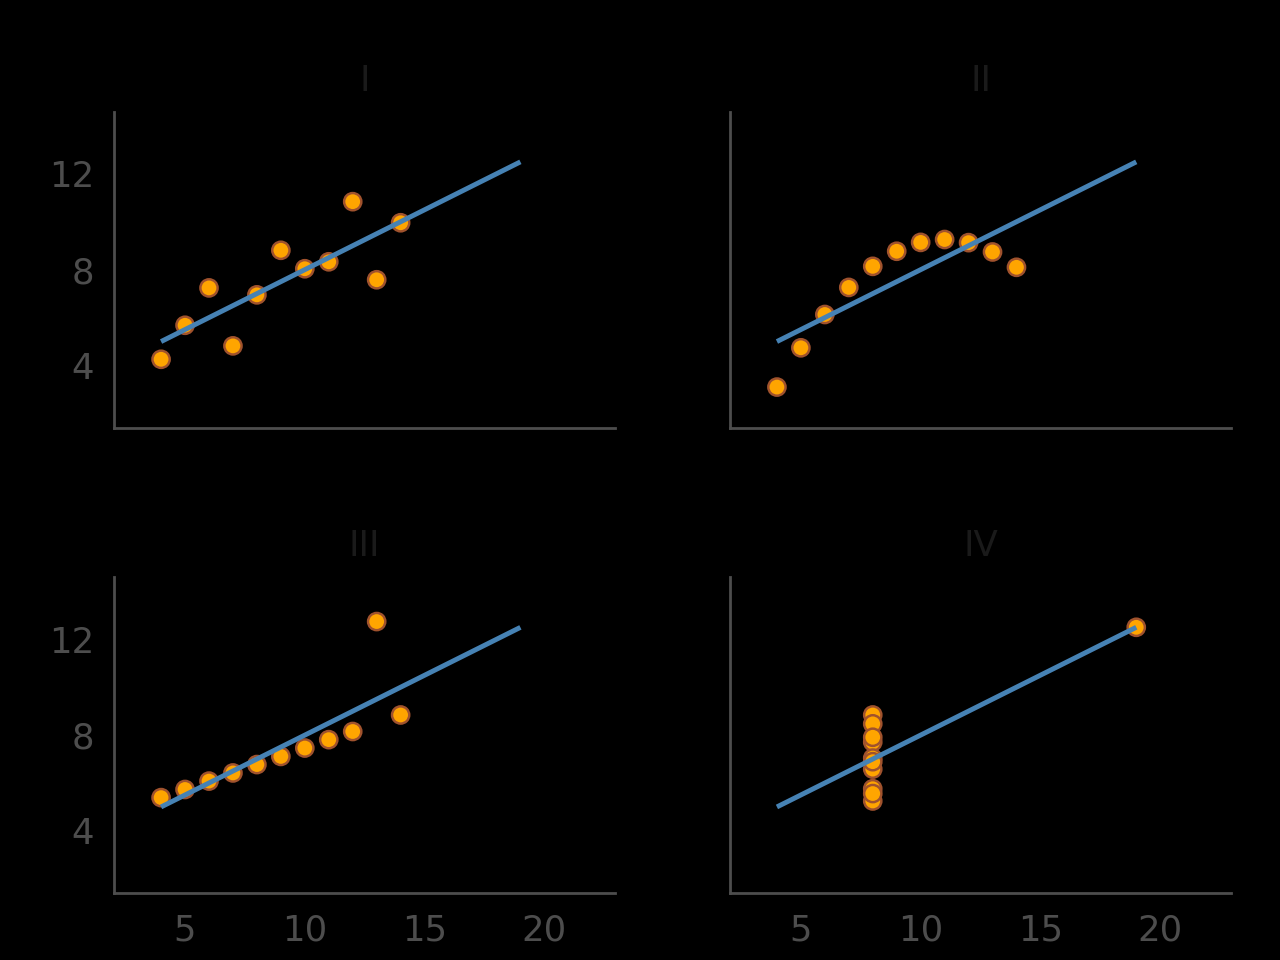

In [15]:
from plotnine import *
from plotnine.data import anscombe_quartet

(
    ggplot(anscombe_quartet, aes("x", "y"))
    + geom_point(color="sienna", fill="orange", size=3)
    + geom_smooth(method="lm", se=False, fullrange=True, color="steelblue", size=1)
    + facet_wrap("dataset")
    + labs(title="Anscombe’s Quartet")
    + scale_y_continuous(breaks=(4, 8, 12))
    + coord_fixed(xlim=(3, 22), ylim=(2, 14))
    + theme_tufte(base_size=16)
    + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.09,
    )
)

c:\Users\paul\programming\courses\python-exercises\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
Extracting 'chicago_commpop/chicago_commpop.geojson' from 'C:\Users\paul\AppData\Local\geodatasets\geodatasets\Cache\chicago_commpop.zip' to 'C:\Users\paul\AppData\Local\geodatasets\geodatasets\Cache\chicago_commpop.zip.unzip'


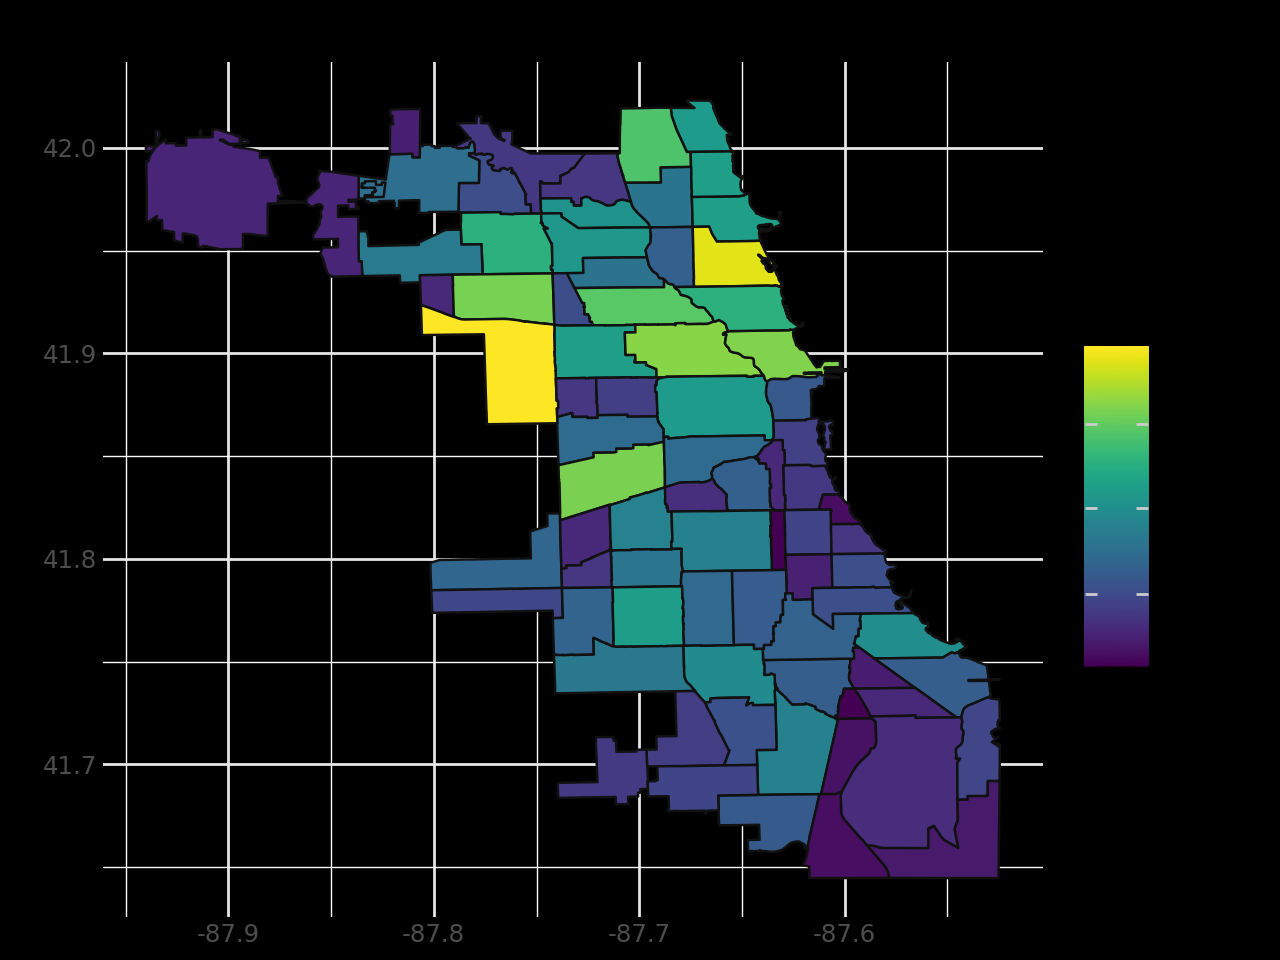

In [16]:
from plotnine import *
import geodatasets
import geopandas as gp

chicago = gp.read_file(geodatasets.get_path("geoda.chicago_commpop"))

(
    ggplot(chicago, aes(fill="POP2010"))
    + geom_map()
    + coord_fixed()
    + theme_minimal()
    + labs(title="Chicago Population in 2010")
)

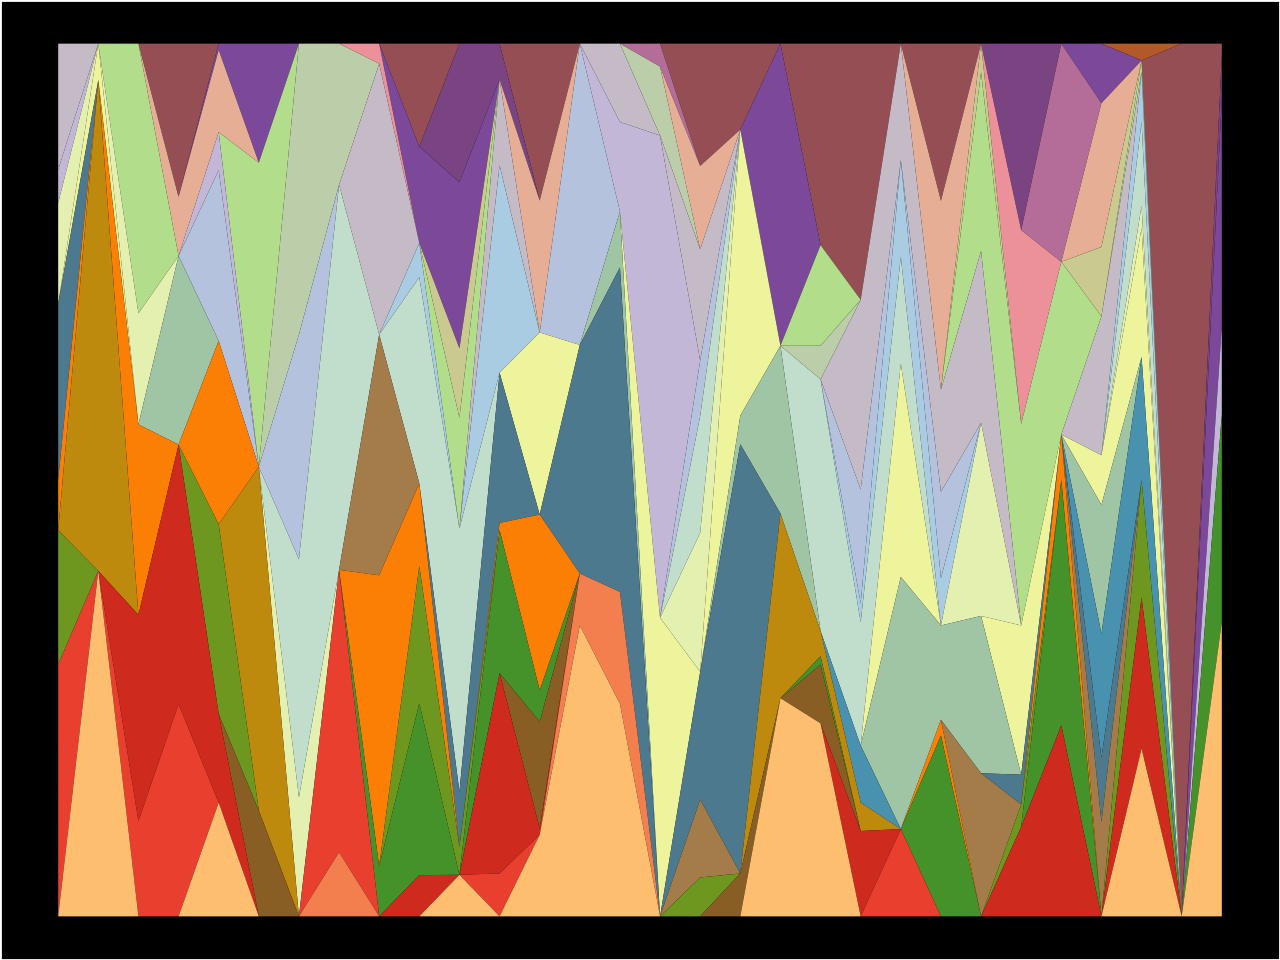

In [17]:
import polars as pl
import numpy as np

from plotnine import *
from mizani.palettes import brewer_pal, gradient_n_pal

np.random.seed(345678)

# generate random areas for each group to fill per year ---------
# Note that in the data the x-axis is called Year, and the
# filled bands are called Group(s)

opts = [0] * 100 + list(range(1, 31))
values = []
for ii in range(30):
    values.extend(np.random.choice(opts, 30, replace=False))


# Put all the data together -------------------------------------
years = pl.DataFrame({"Year": list(range(30))})
groups = pl.DataFrame({"Group": [f"grp_{ii}" for ii in range(30)]})

df = (
    years.join(groups, how="cross")
    .with_columns(Values=pl.Series(values))
    .with_columns(prop=pl.col("Values") / pl.col("Values").sum().over("Year"))
)


# Generate color palette ----------------------------------------
# this uses 12 colors interpolated to all 30 Groups
pal = brewer_pal("qual", "Paired")

colors = pal(12)
np.random.shuffle(colors)

all_colors = gradient_n_pal(colors)(np.linspace(0, 1, 30))


# Plot ---------------------------------------------------------
(
    df
    >> ggplot(aes("Year", "prop", fill="Group"))
    + geom_area()
    + scale_fill_manual(values=all_colors)
    + theme(
        axis_text=element_blank(),
        line=element_blank(),
        title=element_blank(),
        legend_position="none",
        plot_margin=0,
        panel_border=element_blank(),
        panel_background=element_blank(),
    )
)